In [ ]:
from google.colab import files
files.upload()

Saving train.csv to train (1).csv


{'train (1).csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2

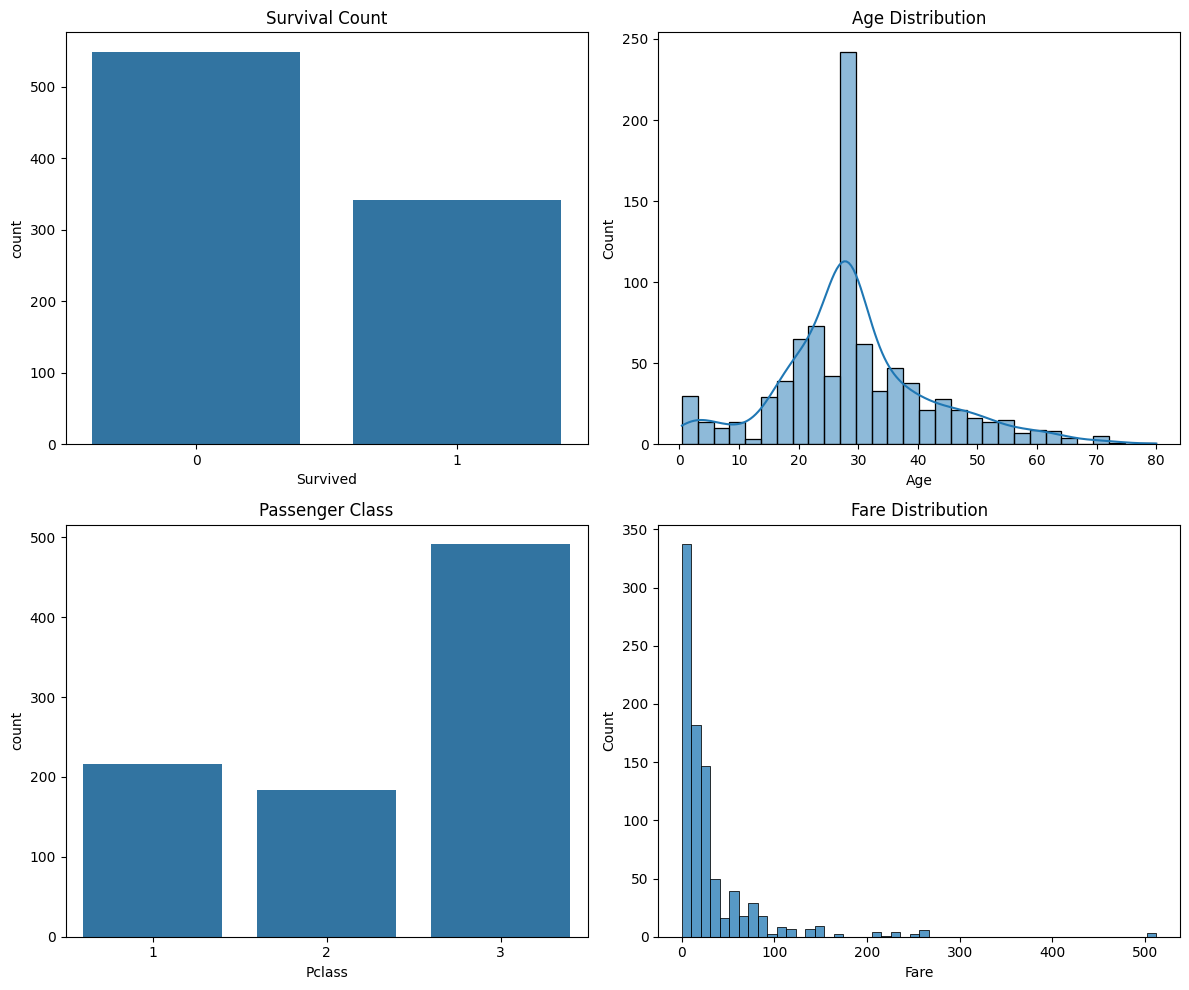

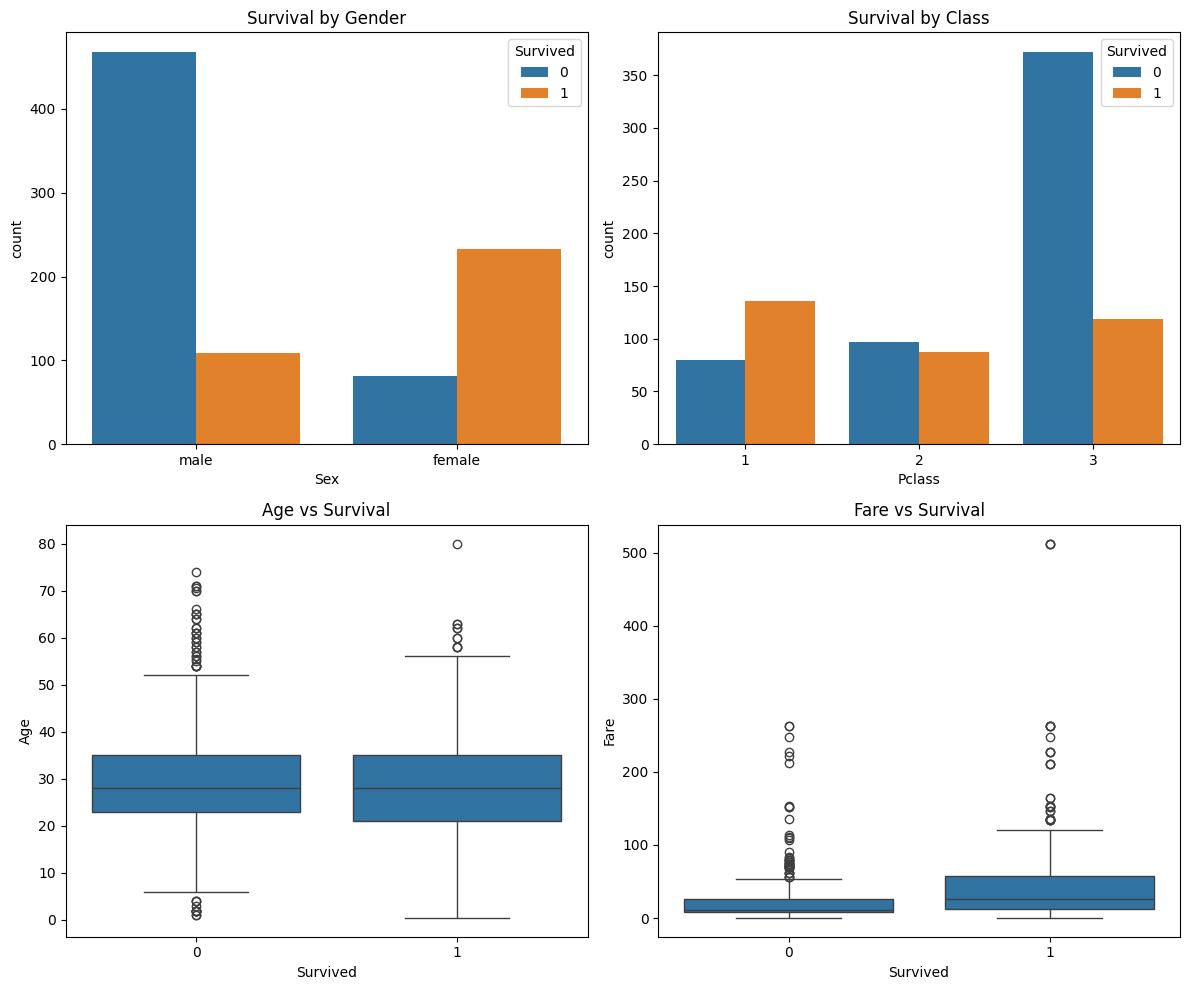

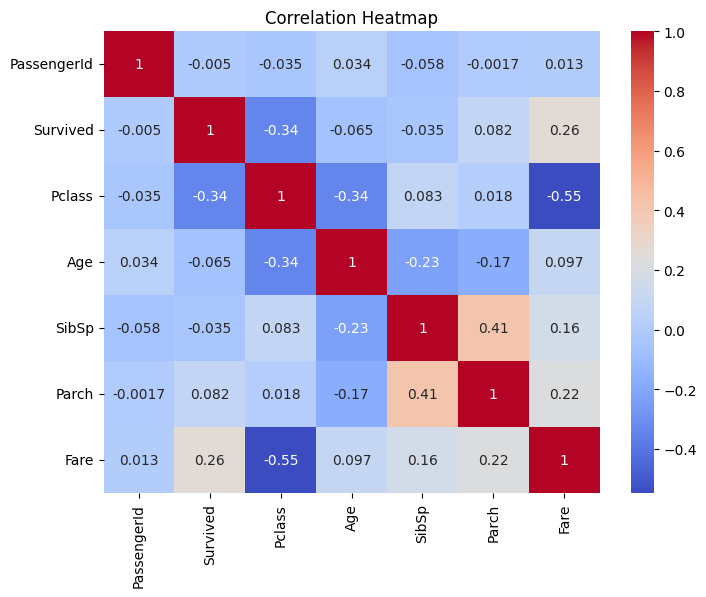


KEY INSIGHTS
Overall survival rate: 38.4%

Survival by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival by class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [ ]:
# ============================================
# COMPLETE EDA CODE - Titanic Dataset
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('train.csv')

# ===== 1. DATA OVERVIEW =====
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nData types:\n", df.dtypes)

# ===== 2. MISSING VALUES =====
print("\nMissing values:\n", df.isnull().sum())

# Handle missing
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)

# ===== 3. STATISTICS =====
print("\nStatistical summary:\n", df.describe())

# ===== 4. UNIVARIATE PLOTS =====
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(x='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Survival Count')

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

sns.countplot(x='Pclass', data=df, ax=axes[1,0])
axes[1,0].set_title('Passenger Class')

sns.histplot(df['Fare'], bins=50, ax=axes[1,1])
axes[1,1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

# ===== 5. BIVARIATE PLOTS =====
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Survival by Gender')

sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title('Survival by Class')

sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1,0])
axes[1,0].set_title('Age vs Survival')

sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1,1])
axes[1,1].set_title('Fare vs Survival')

plt.tight_layout()
plt.show()

# ===== 6. CORRELATION HEATMAP =====
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ===== 7. KEY INSIGHTS =====
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)
print(f"Overall survival rate: {df['Survived'].mean()*100:.1f}%")
print(f"\nSurvival by gender:")
print(df.groupby('Sex')['Survived'].mean())
print(f"\nSurvival by class:")
print(df.groupby('Pclass')['Survived'].mean())